# European Bird Sightings Analysis
## Combining and Analyzing eBird Data from 47 European Countries

This notebook will:
1. Combine all your CSV files into one dataset
2. Perform comprehensive statistical analysis
3. Create visualizations
4. Export results

---

## Setup and Imports

In [114]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from datetime import datetime
import geopandas as gpd

warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## 2. Data Preprocessing

In [115]:
combined_df = pd.read_csv("/Users/dazedinthecity/Documents/GitHub/ceu-ds-project-groupB-2026/ebird/migra_species_europe_only.csv")
combined_df.shape

(878189, 20)

In [116]:
# Load the bird species reference file
# UPDATE THIS PATH if your CSV file is in a different location
reference_file = '/Users/dazedinthecity/Documents/GitHub/ceu-ds-project-groupB-2026/datasets/bird_species_migration.csv'  # Change as needed

try:
    bird_reference = pd.read_csv(reference_file)
    print("✓ Bird species reference file loaded successfully!")
    print(f"\nReference file contains {len(bird_reference)} rows")
    print(f"\nColumns: {bird_reference.columns.tolist()}")
except FileNotFoundError:
    print(f"Error: Could not find '{reference_file}'")
    print("Please update the reference_file path in the cell above.")

Error: Could not find '/Users/dazedinthecity/Documents/GitHub/ceu-ds-project-groupB-2026/datasets/bird_species_migration.csv'
Please update the reference_file path in the cell above.


In [117]:
combined_df.head()

,COMMON NAME,SCIENTIFIC NAME,OBSERVATION COUNT,AGE/SEX,COUNTRY,COUNTRY CODE,STATE,STATE CODE,COUNTY,COUNTY CODE,ATLAS BLOCK,LOCALITY,LOCALITY ID,LOCALITY TYPE,LATITUDE,LONGITUDE,OBSERVATION DATE,OBSERVER ID,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE
0,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,CÃ¡diz,ES-AN-CD,NaN,Isla Tarifa.ES-Tarifa - 36.001x-5.611 - 20 Jan...,L5281087,P,36.001314,-5.610797,2017-01-20,obsr756857,S33804365,Traveling
1,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,NaN,Marismas del Odiel PNat--Isla de Saltes,L1419789,H,37.189895,-6.943853,2017-01-16,obsr271019,S33940654,Traveling
2,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,NaN,Marismas del Odiel PNat--Isla de Saltes,L1419789,H,37.189895,-6.943853,2017-01-16,obsr427437,S33751745,Traveling
3,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,NaN,Marismas del Odiel PNat--Isla de Saltes,L1419789,H,37.189895,-6.943853,2017-01-16,obsr546444,S34018122,Traveling
4,Eurasian Whimbrel,Numenius phaeopus,3.0,NaN,Spain,ES,Canarias,ES-CN,Fuerteventura,ES-CN-FVT,NaN,Salinas del Carmen,L3189830,H,28.367192,-13.869656,2017-01-21,obsr777138,S33908528,Traveling


In [118]:
# Convert date column to datetime
combined_df['obsDt'] = pd.to_datetime(combined_df['OBSERVATION DATE'], errors='coerce')

# Extract temporal features
combined_df['year'] = combined_df['obsDt'].dt.year
combined_df['month'] = combined_df['obsDt'].dt.month
combined_df['day_of_week'] = combined_df['obsDt'].dt.dayofweek
combined_df['day_of_year'] = combined_df['obsDt'].dt.dayofyear

# drop 2026 (it ruins the results)
combined_df = combined_df[combined_df['year'] != 2026]

# Convert count to numeric
combined_df['howMany'] = pd.to_numeric(combined_df['OBSERVATION COUNT'], errors='coerce')

print("✓ Data preprocessing complete!")
print(f"\nDate range: {combined_df['obsDt'].min()} to {combined_df['obsDt'].max()}")
print(f"Years covered: {sorted(combined_df['year'].dropna().unique().astype(int).tolist())}")

✓ Data preprocessing complete!

Date range: 2017-01-01 00:00:00 to 2025-12-31 00:00:00
Years covered: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [119]:
combined_df = combined_df[combined_df['year'] < 2023]

In [120]:
# Load the bird species reference file
# UPDATE THIS PATH if your CSV file is in a different location
reference_file = '/Users/dazedinthecity/Documents/GitHub/ceu-ds-project-groupB-2026/datasets/birds/bird_species_migration.csv'  # Change as needed

try:
    bird_reference = pd.read_csv(reference_file)
    print("✓ Bird species reference file loaded successfully!")
    print(f"\nReference file contains {len(bird_reference)} rows")
    print(f"\nColumns: {bird_reference.columns.tolist()}")
except FileNotFoundError:
    print(f"Error: Could not find '{reference_file}'")
    print("Please update the reference_file path in the cell above.")

✓ Bird species reference file loaded successfully!

Reference file contains 12 rows

Columns: ['bird_species', 'ebird_code', 'migration_period', 'migration_group']


In [121]:
migration_map = dict(zip(
    bird_reference['bird_species'].str.lower(),
    bird_reference['migration_group']
))

# Map migration groups to observations
combined_df['migration_group'] = combined_df['COMMON NAME'].str.lower().map(migration_map)


In [122]:
combined_df['migration_group'].unique()

array(['diurnal & nocturnal', 'nocturnal', 'diurnal'], dtype=object)

In [123]:
combined_df = combined_df[combined_df['migration_group'] != 'diurnal & nocturnal']

## 3. Basic Statistics

In [124]:
# Overall statistics
print("="*80)
print("OVERALL DATASET STATISTICS")
print("="*80)
print(f"\nTotal observations: {len(combined_df):,}")
print(f"Number of countries: {combined_df['COUNTRY CODE'].nunique()}")
print(f"Number of states/regions: {combined_df['STATE CODE'].nunique()}")
print(f"Number of counties: {combined_df['COUNTY CODE'].nunique()}")
print(f"Number of unique species: {combined_df['SCIENTIFIC NAME'].nunique()}")
print(f"Number of locality types: {combined_df['LOCALITY TYPE'].nunique()}")
print(f"Number of observation types: {combined_df['OBSERVATION TYPE'].nunique()}")
print(f"Number of unique observers: {combined_df['OBSERVER ID'].nunique()}")

# Count data statistics
count_data = combined_df[combined_df['howMany'].notna()]
print(f"\nObservations with count data: {len(count_data):,} ({len(count_data)/len(combined_df)*100:.1f}%)")
if len(count_data) > 0:
    print(f"Total birds counted: {count_data['howMany'].sum():,.0f}")
    print(f"Average count per observation: {count_data['howMany'].mean():.2f}")
    print(f"Median count: {count_data['howMany'].median():.0f}")
    print(f"Maximum count in single observation: {count_data['howMany'].max():,.0f}")
    print(f"Minimum count: {count_data['howMany'].min():.0f}")

OVERALL DATASET STATISTICS

Total observations: 679,092
Number of countries: 46
Number of states/regions: 669
Number of counties: 1041
Number of unique species: 9
Number of locality types: 2
Number of observation types: 8
Number of unique observers: 19154

Observations with count data: 679,092 (100.0%)
Total birds counted: 15,304,963
Average count per observation: 22.54
Median count: 2
Maximum count in single observation: 140,000
Minimum count: 1


### outlier removal for col 'howMany'

In [125]:
Q1 = combined_df['howMany'].quantile(0.25)
Q3 = combined_df['howMany'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = combined_df[(combined_df['howMany'] < lower_bound) | (combined_df['howMany'] > upper_bound)]

print("="*80)
print("OUTLIER ANALYSIS: howMany")
print("="*80)
print(f"\nQ1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")
print(f"\nTotal outliers: {len(outliers):,} ({len(outliers)/len(combined_df)*100:.2f}% of data)")
print(f"\nOutlier summary:")
print(outliers['howMany'].describe())

OUTLIER ANALYSIS: howMany

Q1: 1.0
Q3: 5.0
IQR: 4.0
Lower bound: -5.0
Upper bound: 11.0

Total outliers: 90,048 (13.26% of data)

Outlier summary:
count     90048.000000
mean        153.189821
std        2046.675700
min          12.000000
25%          16.000000
50%          26.000000
75%          50.000000
max      140000.000000
Name: howMany, dtype: float64


In [126]:
print("="*80)
print("OUTLIER DISTRIBUTION: howMany")
print("="*80)

# Value counts for outliers
outlier_dist = outliers['howMany'].value_counts().sort_index()

print(f"\nTop 20 most frequent outlier values:")
print(outliers['howMany'].value_counts().head(20))

print(f"\nOutlier range distribution (binned):")
bins = [lower_bound, 50, 100, 500, 1000, 5000, float('inf')]
labels = [f'{int(lower_bound)}-50', '51-100', '101-500', '501-1000', '1001-5000', '5000+']
outlier_binned = pd.cut(outliers['howMany'], bins=bins, labels=labels)
print(outlier_binned.value_counts().sort_index())

print(f"\nKey outlier statistics:")
print(f"  Min outlier value:    {outliers['howMany'].min():,.0f}")
print(f"  Max outlier value:    {outliers['howMany'].max():,.0f}")
print(f"  Mean outlier value:   {outliers['howMany'].mean():,.2f}")
print(f"  Median outlier value: {outliers['howMany'].median():,.0f}")

OUTLIER DISTRIBUTION: howMany

Top 20 most frequent outlier values:
howMany
20.0     8402
15.0     7118
12.0     7086
30.0     5499
50.0     3804
25.0     3598
14.0     3360
40.0     3153
13.0     2786
16.0     2545
18.0     2268
100.0    2064
17.0     1893
60.0     1683
35.0     1560
22.0     1336
19.0     1296
80.0     1147
200.0    1141
21.0     1119
Name: count, dtype: int64

Outlier range distribution (binned):
howMany
-5-50        68323
51-100       11225
101-500       8541
501-1000       885
1001-5000      816
5000+          258
Name: count, dtype: int64

Key outlier statistics:
  Min outlier value:    12
  Max outlier value:    140,000
  Mean outlier value:   153.19
  Median outlier value: 26


In [127]:
high_outliers = outliers[outliers['howMany'] > 100]

print("="*80)
print("LOCALITY TYPES FOR OUTLIERS WHERE howMany > 100")
print("="*80)
print(f"\nTotal rows with howMany > 100: {len(high_outliers):,}")
print(f"\nLocality Type Distribution:")
print(high_outliers['LOCALITY TYPE'].value_counts())
print(f"\nLocality Type Proportions:")
print(high_outliers['LOCALITY TYPE'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

LOCALITY TYPES FOR OUTLIERS WHERE howMany > 100

Total rows with howMany > 100: 10,500

Locality Type Distribution:
LOCALITY TYPE
H    8555
P    1945
Name: count, dtype: int64

Locality Type Proportions:
LOCALITY TYPE
H    81.48%
P    18.52%
Name: proportion, dtype: object


#### dropping outliers

In [128]:
before = len(combined_df)
combined_df = combined_df[combined_df['howMany'] <= 100]
after = len(combined_df)

print("="*80)
print("AFTER DROPPING howMany > 100")
print("="*80)
print(f"\nRows before: {before:,}")
print(f"Rows after:  {after:,}")
print(f"Rows dropped: {before - after:,} ({(before - after)/before*100:.2f}% of data)")

AFTER DROPPING howMany > 100

Rows before: 679,092
Rows after:  668,592
Rows dropped: 10,500 (1.55% of data)


## 4. Analysis by Country

In [129]:
print(combined_df['STATE'].isna().sum(),combined_df['COUNTY'].isna().sum())

0 212794


In [130]:
country_stats = combined_df.groupby(['COUNTRY CODE', 'COUNTRY']).agg(
    total_observations=('SAMPLING EVENT IDENTIFIER', 'count'),
    unique_species=('SCIENTIFIC NAME', 'nunique'),
    unique_states=('STATE', 'nunique'),
    unique_counties=('COUNTY', 'nunique'),
    total_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0)
).reset_index()

country_stats.columns = ['Country Code', 'Country Name', 'Total Observations', 
                         'Unique Species', 'Unique States', 'Unique Counties', 
                         'Total Birds Counted']

country_stats = country_stats.sort_values('Total Observations', ascending=False)

print("\nSTATISTICS BY COUNTRY")
print("="*120)
print(country_stats.to_string(index=False))


STATISTICS BY COUNTRY
Country Code           Country Name  Total Observations  Unique Species  Unique States  Unique Counties  Total Birds Counted
          ES                  Spain              211546               9             19               48            1159144.0
          GB         United Kingdom              113284               9              4              103             622267.0
          PT               Portugal               74831               9             20              278             463170.0
          DE                Germany               28431               9             16              327             156027.0
          FR                 France               28332               9             13               96             157898.0
          PL                 Poland               21803               9             16                0             169929.0
          SE                 Sweden               21344               9             21                

In [131]:
country_stats = combined_df.groupby(['COUNTRY CODE', 'COUNTRY']).agg(
    total_observations=('SAMPLING EVENT IDENTIFIER', 'count'),
    unique_species=('SCIENTIFIC NAME', 'nunique'),
    unique_states=('STATE', 'nunique'),
    unique_counties=('COUNTY', 'nunique'),
    total_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0),
    unique_observers=('OBSERVER ID', 'nunique')
).reset_index()

country_stats.columns = ['Country Code', 'Country Name', 'Total Observations', 
                         'Unique Species', 'Unique States', 'Unique Counties', 
                         'Total Birds Counted', 'Unique Observers']

country_stats = country_stats.sort_values('Unique Observers', ascending=False)

print("\nSTATISTICS BY COUNTRY")
print("="*120)
print(country_stats.to_string(index=False))


STATISTICS BY COUNTRY
Country Code           Country Name  Total Observations  Unique Species  Unique States  Unique Counties  Total Birds Counted  Unique Observers
          ES                  Spain              211546               9             19               48            1159144.0              6282
          GB         United Kingdom              113284               9              4              103             622267.0              4575
          PT               Portugal               74831               9             20              278             463170.0              2471
          FR                 France               28332               9             13               96             157898.0              1903
          DE                Germany               28431               9             16              327             156027.0              1382
          NL            Netherlands               13223               9             12                2              81

### relative to number of observers

In [132]:
country_stats = combined_df.groupby(['COUNTRY CODE', 'COUNTRY']).agg(
    total_observations=('SAMPLING EVENT IDENTIFIER', 'count'),
    unique_species=('SCIENTIFIC NAME', 'nunique'),
    unique_states=('STATE', 'nunique'),
    unique_counties=('COUNTY', 'nunique'),
    total_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0),
    unique_observers=('OBSERVER ID', 'nunique')
).reset_index()

country_stats.columns = ['Country Code', 'Country Name', 'Total Observations', 
                         'Unique Species', 'Unique States', 'Unique Counties', 
                         'Total Birds Counted', 'Unique Observers']

# Calculate per-observer metrics
country_stats['Obs per Observer']      = (country_stats['Total Observations'] / country_stats['Unique Observers']).round(1)
# country_stats['Species per Observer']  = (country_stats['Unique Species']      / country_stats['Unique Observers']).round(1)
# country_stats['Birds per Observer']    = (country_stats['Total Birds Counted'] / country_stats['Unique Observers']).round(1)
# country_stats['Counties per Observer'] = (country_stats['Unique Counties']     / country_stats['Unique Observers']).round(2)

country_stats = country_stats.sort_values('Obs per Observer', ascending=False)

print("\nSTATISTICS BY COUNTRY (relative to unique observers)")
print("="*150)
print(country_stats.to_string(index=False))


STATISTICS BY COUNTRY (relative to unique observers)
Country Code           Country Name  Total Observations  Unique Species  Unique States  Unique Counties  Total Birds Counted  Unique Observers  Obs per Observer
          MD                Moldova                1619               8             33                0              18004.0                28              57.8
          CZ         Czech Republic               17264               9             14                0             100785.0               386              44.7
          PL                 Poland               21803               9             16                0             169929.0               619              35.2
          ES                  Spain              211546               9             19               48            1159144.0              6282              33.7
          RS                 Serbia                4700               9             18                0              39392.0               14

## 5. Species Analysis

In [133]:
# Species statistics
species_stats = combined_df.groupby(['COMMON NAME', 'SCIENTIFIC NAME']).agg({
    'SAMPLING EVENT IDENTIFIER': 'count',
    'COUNTRY CODE': 'nunique',
    'STATE CODE': 'nunique',
    'howMany': lambda x: x.sum() if x.notna().any() else 0
}).reset_index()

species_stats.columns = ['Common Name', 'Scientific Name', 
                        'Total Observations', 'Countries Found', 'States Found', 'Total Count']

species_stats = species_stats.sort_values('Total Observations', ascending=False)

print("\nTOP 30 MOST OBSERVED SPECIES")
print("="*120)
print(species_stats.head(30).to_string(index=False))


TOP 30 MOST OBSERVED SPECIES
           Common Name     Scientific Name  Total Observations  Countries Found  States Found  Total Count
       Green Sandpiper     Tringa ochropus              173660               44           557     413116.0
                  Ruff     Calidris pugnax              109964               42           491     951843.0
            Sanderling       Calidris alba               85484               42           305     984336.0
        Wood Sandpiper     Tringa glareola               74871               42           523     418857.0
              Garganey Spatula querquedula               52675               43           511     233464.0
          Little Stint     Calidris minuta               51689               43           383     286413.0
European Honey-buzzard     Pernis apivorus               44529               42           545     208528.0
              Red Knot    Calidris canutus               39126               40           273     316233.0
      C

## 6. Temporal Analysis


TEMPORAL ANALYSIS

Observations by Year:
  2017: 59,795
  2018: 70,218
  2019: 91,941
  2020: 104,121
  2021: 146,936
  2022: 195,581

Observations by month of 2017


  January: 2,851
  February: 1,794
  March: 3,853
  April: 7,630
  May: 6,673
  June: 2,399
  July: 4,462
  August: 9,287
  September: 9,941
  October: 5,235
  November: 2,737
  December: 2,933
  → Peak migration month: September (9,941 observations)

Observations by month of 2018
  January: 3,535
  February: 2,784
  March: 4,357
  April: 8,207
  May: 9,698
  June: 3,179
  July: 6,242
  August: 10,769
  September: 10,688
  October: 4,681
  November: 2,844
  December: 3,234
  → Peak migration month: August (10,769 observations)

Observations by month of 2019
  January: 4,125
  February: 3,241
  March: 6,894
  April: 12,095
  May: 10,982
  June: 3,605
  July: 7,930
  August: 15,021
  September: 13,903
  October: 6,251
  November: 3,858
  December: 4,036
  → Peak migration month: August (15,021 observations)

Observations by month of 2020
  January: 5,086
  February: 4,075
  March: 4,937
  April: 7,679
  May: 9,848
  June: 4,359
  July: 10,026
  August: 20,524
  September: 19,770
  Octobe

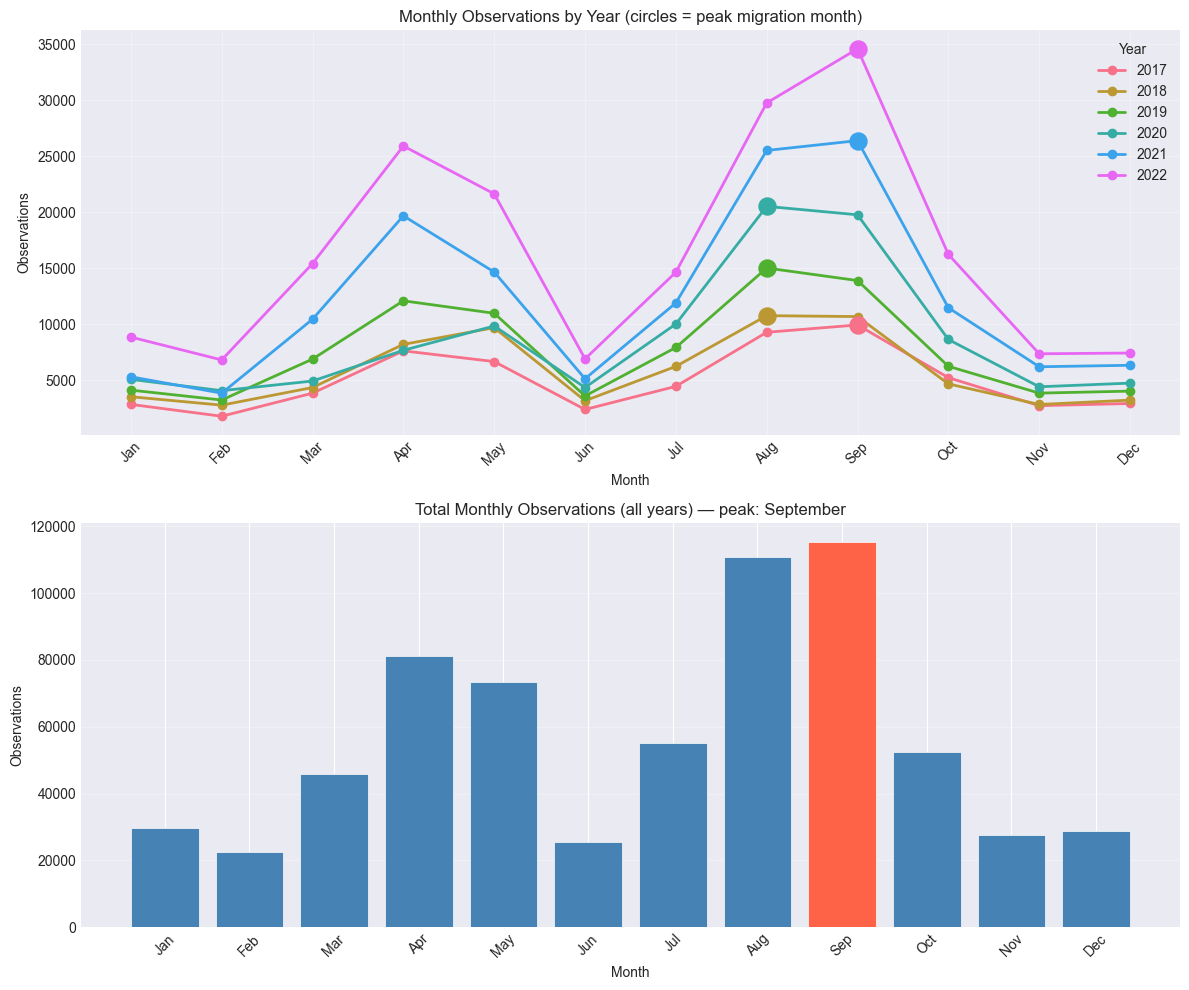

In [134]:
# Temporal distribution
print("\nTEMPORAL ANALYSIS")
print("="*60)

# By year
yearly_obs = combined_df.groupby('year').size().sort_index()
print("\nObservations by Year:")
for year, count in yearly_obs.items():
    if pd.notna(year):
        print(f"  {int(year)}: {count:,}")

# Month each year
month_names = {1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June',
               7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'}

peak_months_by_year = {}  # store peak month per year

yearly_obs = combined_df.groupby('year').size().sort_index()
for year in yearly_obs.index:
    print("\nObservations by month of", int(year))
    monthly_obs = combined_df[combined_df['year'] == year].groupby('month').size().sort_index()
    for month, count in monthly_obs.items():
        if pd.notna(month):
            print(f"  {month_names[int(month)]}: {count:,}")
    
    # Save peak month for this year
    peak_month = monthly_obs.idxmax()
    if pd.notna(peak_month):
        peak_months_by_year[int(year)] = {
            'month': int(peak_month),
            'month_name': month_names[int(peak_month)],
            'count': monthly_obs.max()
        }
        print(f"  → Peak migration month: {month_names[int(peak_month)]} ({monthly_obs.max():,} observations)")

# By month (all years combined)
monthly_obs = combined_df.groupby('month').size().sort_index()
print("\nObservations by Month (all years):")
for month, count in monthly_obs.items():
    if pd.notna(month):
        print(f"  {month_names[int(month)]}: {count:,}")

# Peak observation period
peak_month = monthly_obs.idxmax()
if pd.notna(peak_month):
    print(f"\nPeak observation month: {month_names[int(peak_month)]} ({monthly_obs.max():,} observations)")

# Print summary of peak months
print("\nPeak Migration Month by Year:")
for year, info in peak_months_by_year.items():
    print(f"  {year}: {info['month_name']} ({info['count']:,} observations)")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Monthly observations per year (lines)
ax1 = axes[0]
for year in yearly_obs.index:
    if pd.notna(year):
        monthly = combined_df[combined_df['year'] == year].groupby('month').size().reindex(range(1, 13), fill_value=0)
        ax1.plot(range(1, 13), monthly.values, marker='o', label=str(int(year)), linewidth=2)
        # Mark peak month
        if int(year) in peak_months_by_year:
            pm = peak_months_by_year[int(year)]['month']
            ax1.scatter(pm, monthly[pm], s=150, zorder=5)

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels([month_names[m][:3] for m in range(1, 13)], rotation=45)
ax1.set_title('Monthly Observations by Year (circles = peak migration month)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Observations')
ax1.legend(title='Year')
ax1.grid(True, alpha=0.3)

# Plot 2: Combined monthly observations (bar)
ax2 = axes[1]
colors = ['tomato' if m == int(peak_month) else 'steelblue' for m in range(1, 13)]
monthly_all = combined_df.groupby('month').size().reindex(range(1, 13), fill_value=0)
bars = ax2.bar(range(1, 13), monthly_all.values, color=colors, edgecolor='white', linewidth=0.5)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels([month_names[m][:3] for m in range(1, 13)], rotation=45)
ax2.set_title(f'Total Monthly Observations (all years) — peak: {month_names[int(peak_month)]}')
ax2.set_xlabel('Month')
ax2.set_ylabel('Observations')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
#plt.savefig('temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
#print("\nPlot saved as 'temporal_analysis.png'")

In [135]:
# Temporal distribution
print("\nTEMPORAL ANALYSIS")
print("="*60)

# By year
yearly_obs = combined_df.groupby('year').agg(
    observations=('OBSERVER ID', 'count'),
    number_of_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0)
).sort_index()

print("\nObservations by Year:")
for year, row in yearly_obs.iterrows():
    if pd.notna(year):
        print(f"  {int(year)}: {row['observations']:,} observations | {row['number_of_birds']:,} number of birds counted")
        #print(f"    Avg obs per observer: {(row['observations'] / row['unique_observers']):.2f}")




TEMPORAL ANALYSIS

Observations by Year:
  2017: 59,795.0 observations | 353,731.0 number of birds counted
  2018: 70,218.0 observations | 429,188.0 number of birds counted
  2019: 91,941.0 observations | 548,251.0 number of birds counted
  2020: 104,121.0 observations | 630,295.0 number of birds counted
  2021: 146,936.0 observations | 879,950.0 number of birds counted
  2022: 195,581.0 observations | 1,155,579.0 number of birds counted


In [136]:
# Temporal distribution
print("\nTEMPORAL ANALYSIS")
print("="*60)

# By year
yearly_obs = combined_df.groupby('year').agg(
    observations=('OBSERVER ID', 'count'),
    unique_observers=('OBSERVER ID', 'nunique'),
    number_of_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0)
).sort_index()

print("\nObservations by Year:")
for year, row in yearly_obs.iterrows():
    if pd.notna(year):
        print(f"  {int(year)}: {row['number_of_birds']:,} number of birds counted | {row['unique_observers']:,} unique observers")
        print(f"    Avg bird per observer: {(row['number_of_birds'] / row['unique_observers']):.2f}")
        print(f"  {int(year)}: {row['observations']:,} observations | {row['unique_observers']:,} unique observers")
        print(f"    Avg obs per observer: {(row['observations'] / row['unique_observers']):.2f}")




TEMPORAL ANALYSIS

Observations by Year:
  2017: 353,731.0 number of birds counted | 4,179.0 unique observers
    Avg bird per observer: 84.64
  2017: 59,795.0 observations | 4,179.0 unique observers
    Avg obs per observer: 14.31
  2018: 429,188.0 number of birds counted | 5,211.0 unique observers
    Avg bird per observer: 82.36
  2018: 70,218.0 observations | 5,211.0 unique observers
    Avg obs per observer: 13.47
  2019: 548,251.0 number of birds counted | 6,364.0 unique observers
    Avg bird per observer: 86.15
  2019: 91,941.0 observations | 6,364.0 unique observers
    Avg obs per observer: 14.45
  2020: 630,295.0 number of birds counted | 6,181.0 unique observers
    Avg bird per observer: 101.97
  2020: 104,121.0 observations | 6,181.0 unique observers
    Avg obs per observer: 16.85
  2021: 879,950.0 number of birds counted | 8,321.0 unique observers
    Avg bird per observer: 105.75
  2021: 146,936.0 observations | 8,321.0 unique observers
    Avg obs per observer: 17.66

<bound method XAxis.set of <matplotlib.axis.XAxis object at 0x137bec190>>

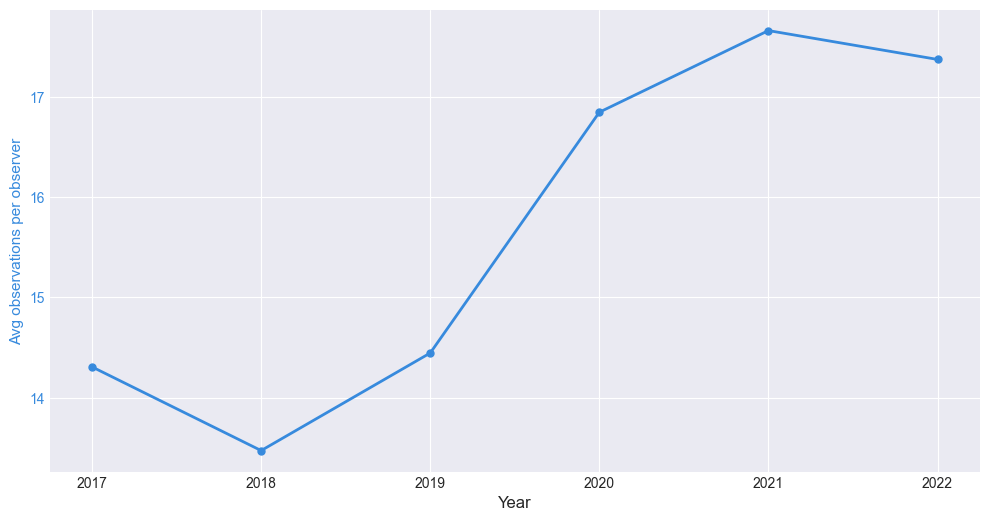

In [137]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

yearly_obs = combined_df.groupby('year').agg(
    observations=('OBSERVER ID', 'count'),
    unique_observers=('OBSERVER ID', 'nunique'),
    number_of_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0)
).sort_index()

yearly_obs = yearly_obs[yearly_obs.index.notna()]
yearly_obs.index = yearly_obs.index.astype(int)

yearly_obs['avg_obs_per_observer'] = yearly_obs['observations'] / yearly_obs['unique_observers']
yearly_obs['avg_birds_per_observer'] = yearly_obs['number_of_birds'] / yearly_obs['unique_observers']

fig, ax1 = plt.subplots(figsize=(12, 6))

color_obs = '#378ADD'
color_birds = '#D85A30'

ax1.plot(yearly_obs.index, yearly_obs['avg_obs_per_observer'],
         color=color_obs, marker='o', linewidth=2, markersize=5, label='Avg obs per observer')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Avg observations per observer', color=color_obs, fontsize=11)
ax1.tick_params(axis='y', labelcolor=color_obs)
ax1.xaxis.set

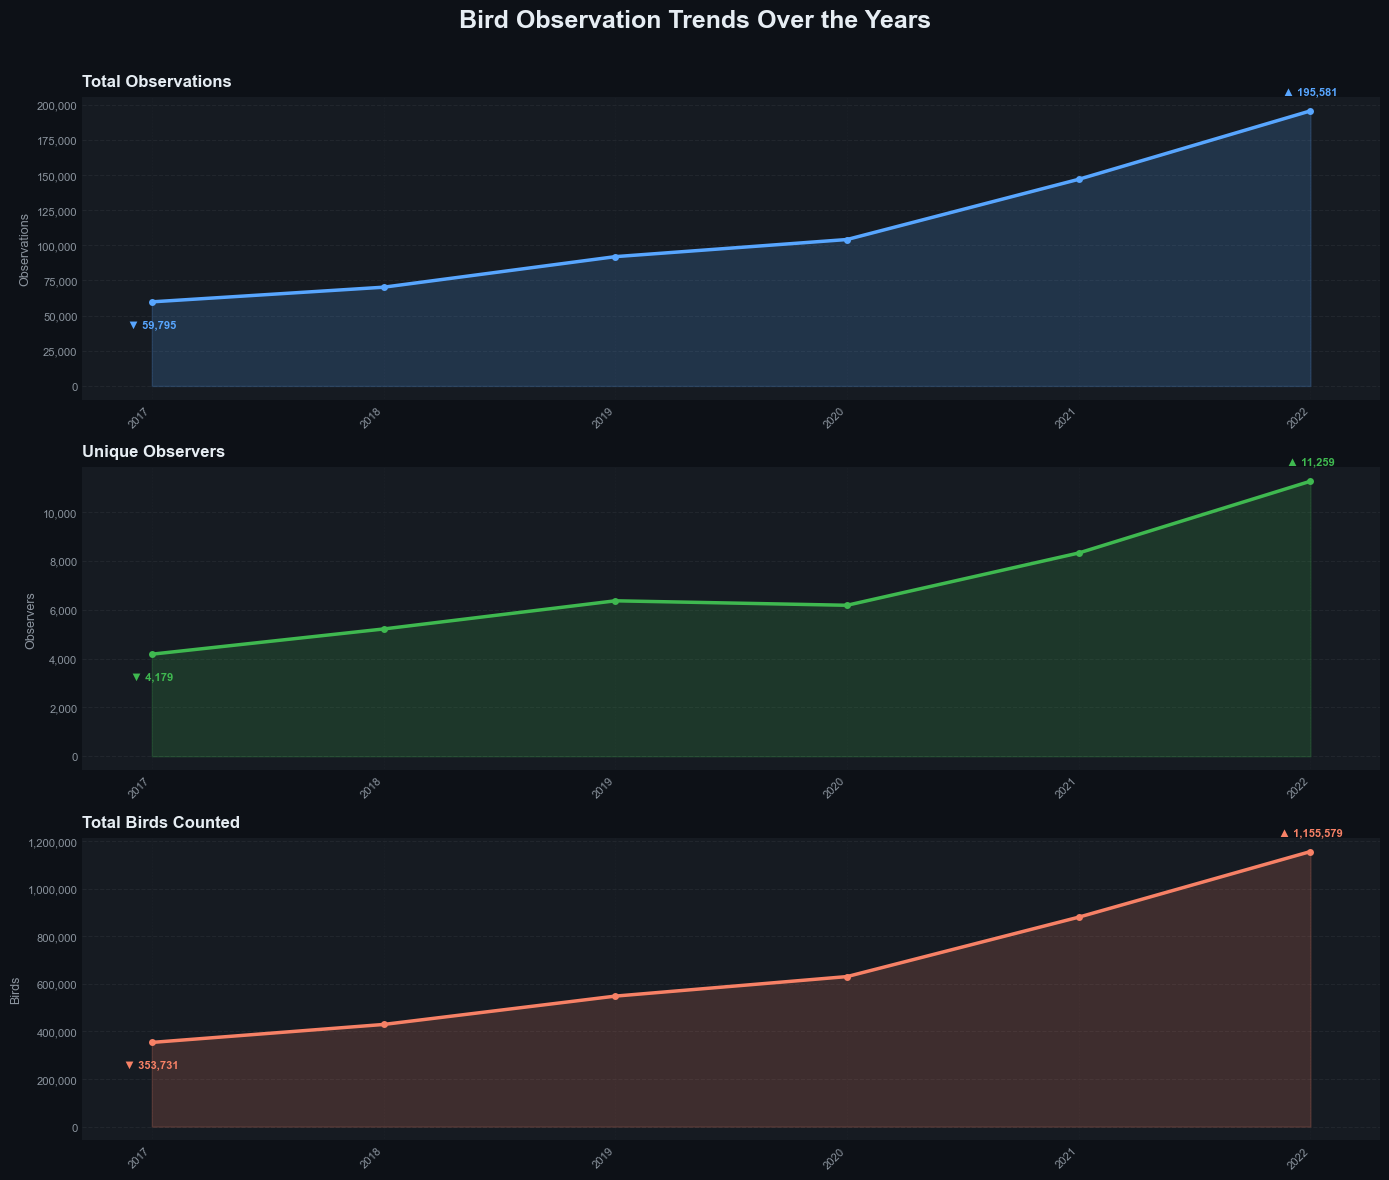

Plot saved to yearly_trends.png


In [138]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(14, 12), facecolor='#0d1117')
fig.suptitle('Bird Observation Trends Over the Years', 
             fontsize=18, fontweight='bold', color='#e6edf3', y=0.98)

years = yearly_obs.index.astype(int)

metrics = [
    ('observations',     '#58a6ff', 'Total Observations',     'Observations'),
    ('unique_observers', '#3fb950', 'Unique Observers',        'Observers'),
    ('number_of_birds',  '#f78166', 'Total Birds Counted',     'Birds'),
]

for ax, (col, color, title, ylabel) in zip(axes, metrics):
    values = yearly_obs[col].values

    ax.set_facecolor('#161b22')
    ax.fill_between(years, values, alpha=0.18, color=color)
    ax.plot(years, values, color=color, linewidth=2.5, marker='o',
            markersize=5, markerfacecolor=color, markeredgewidth=0)

    # Annotate min/max
    max_idx, min_idx = values.argmax(), values.argmin()
    for idx, label in [(max_idx, f'▲ {values[max_idx]:,.0f}'), 
                       (min_idx, f'▼ {values[min_idx]:,.0f}')]:
        ax.annotate(label, xy=(years[idx], values[idx]),
                    xytext=(0, 12 if idx == max_idx else -18),
                    textcoords='offset points', ha='center',
                    fontsize=8, color=color, fontweight='bold')

    ax.set_title(title, fontsize=12, color='#e6edf3', pad=8, loc='left', fontweight='bold')
    ax.set_ylabel(ylabel, color='#8b949e', fontsize=9)
    ax.tick_params(colors='#8b949e', labelsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.set_xlim(years[0] - 0.3, years[-1] + 0.3)
    ax.set_xticks(years)
    ax.set_xticklabels([str(y) for y in years], rotation=45, ha='right')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')
    ax.grid(axis='y', color='#21262d', linewidth=0.8, linestyle='--')
    ax.grid(axis='x', color='#21262d', linewidth=0.4, linestyle=':')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('yearly_trends.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Plot saved to yearly_trends.png")

### Year and locality type

In [139]:
yearly_obs = combined_df.groupby('year').size().sort_index()

print("\nObservations by Year:")
for year, count in yearly_obs.items():
    if pd.notna(year):
        print(f"  {int(year)}: {count:,}")
        locality_counts = (
            combined_df[combined_df['year'] == year]
            .groupby('LOCALITY TYPE')
            .size()
            .sort_values(ascending=False)
        )
        for locality, loc_count in locality_counts.items():
            print(f"    {locality}: {loc_count:,}")

        h = locality_counts.get('H', 0)
        p = locality_counts.get('P', 0)
        diff = h - p
        sign = "+" if diff > 0 else ""
        print(f"    H - P = {sign}{diff:,}")


Observations by Year:
  2017: 59,795
    H: 47,296
    P: 12,499
    H - P = +34,797
  2018: 70,218
    H: 55,865
    P: 14,353
    H - P = +41,512
  2019: 91,941
    H: 74,838
    P: 17,103
    H - P = +57,735
  2020: 104,121
    H: 85,195
    P: 18,926
    H - P = +66,269
  2021: 146,936
    H: 121,259
    P: 25,677
    H - P = +95,582
  2022: 195,581
    H: 163,395
    P: 32,186
    H - P = +131,209


In [140]:
yearly_obs = combined_df.groupby('year').agg(
    observations=('OBSERVER ID', 'count'),
    unique_observers=('OBSERVER ID', 'nunique'),
    number_of_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0)
).sort_index()

print("\nObservations by Year:")
for year, row in yearly_obs.iterrows():
    if pd.notna(year):
        print(f"  {int(year)}: {int(row['number_of_birds']):,} birds")
        locality_birds = (
            combined_df[combined_df['year'] == year]
            .groupby('LOCALITY TYPE')['howMany']
            .sum()
            .sort_values(ascending=False)
        )
        for locality, birds in locality_birds.items():
            print(f"    {locality}: {int(birds):,}")

        h = locality_birds.get('H', 0)
        p = locality_birds.get('P', 0)
        diff = h - p
        sign = "+" if diff > 0 else ""
        print(f"    H - P = {sign}{int(diff):,}")


Observations by Year:
  2017: 353,731 birds
    H: 279,820
    P: 73,911
    H - P = +205,909
  2018: 429,188 birds
    H: 346,739
    P: 82,449
    H - P = +264,290
  2019: 548,251 birds
    H: 451,492
    P: 96,759
    H - P = +354,733
  2020: 630,295 birds
    H: 523,360
    P: 106,935
    H - P = +416,425
  2021: 879,950 birds
    H: 730,960
    P: 148,990
    H - P = +581,970
  2022: 1,155,579 birds
    H: 980,299
    P: 175,280
    H - P = +805,019


### by Season

Analyzing bird sightings based on migration groups across different seasonal periods:
- **Spring Migration Period**: Mid-March to Mid-June
- **Summer Period**: July to Early August
- **Autumn Migration Period**: Late August to Early December  
- **Winter Period**: Late December to Early March

In [141]:
# Define seasonal periods
def get_season(date):
    """
    Classify observation date into seasonal periods.
    """
    if pd.isna(date):
        return 'Unknown'
    
    month = date.month
    day = date.day
    
    # Spring Migration: Mid-March (Mar 15) to Mid-June (Jun 15)
    if (month == 3 and day >= 15) or (month in [4, 5]) or (month == 6 and day <= 15):
        return 'Spring Migration (Mid-Mar to Mid-Jun)'
    
    # Summer: July and Early August (to Aug 20)
    elif month == 7 or (month == 8 and day <= 20):
        return 'Summer (Jul to Early Aug)'
    
    # Autumn Migration: Late August (Aug 21) to Early December (Dec 10)
    elif (month == 8 and day > 20) or (month in [9, 10, 11]) or (month == 12 and day <= 10):
        return 'Autumn Migration (Late Aug to Early Dec)'
    
    # Winter: Late December (Dec 11+) to Early March (Mar 14)
    else:  # (month == 12 and day > 10) or (month in [1, 2]) or (month == 3 and day < 15)
        return 'Winter (Late Dec to Early Mar)'

# Apply seasonal classification
combined_df['season'] = combined_df['obsDt'].apply(get_season)

print("Observations by season:")
season_counts = combined_df['season'].value_counts()
for season, count in season_counts.items():
    print(f"  {season}: {count:,} observations")

Observations by season:
  Autumn Migration (Late Aug to Early Dec): 251,509 observations
  Spring Migration (Mid-Mar to Mid-Jun): 198,614 observations
  Summer (Jul to Early Aug): 119,614 observations
  Winter (Late Dec to Early Mar): 98,855 observations


## 7. Distance to cities

In [142]:
# Load European cities
url = "https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_populated_places.zip"
world = gpd.read_file(url)
europe = world[world.geometry.x.between(-25, 45) & world.geometry.y.between(34, 72)]
cities = europe[['NAME', 'ADM0NAME', 'geometry']].copy()
cities['lon'] = cities.geometry.x
cities['lat'] = cities.geometry.y
cities = cities.drop(columns='geometry').reset_index(drop=True)
cities

,NAME,ADM0NAME,lon,lat
0,L'Ariana,Tunisia,10.199998,36.866673
1,Jendouba,Tunisia,8.749999,36.500004
2,Kasserine,Tunisia,8.716698,35.216703
3,Sdid Bouzid,Tunisia,9.500004,35.016696
4,Siliana,Tunisia,9.383302,36.083304
...,...,...,...,...
1143,London,United Kingdom,-0.118668,51.501941
1144,Istanbul,Turkey,28.974277,41.017602
1145,Moscow,Russia,37.613577,55.754110
1146,Rome,Italy,12.481313,41.897902


In [143]:
df_migratory = combined_df

In [144]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# build KD-Tree on city coordinates ---
# convert lat/lon to radians for accurate distance calculation
cities_rad = np.radians(cities[['lat', 'lon']].values)
tree = cKDTree(cities_rad)

# find closest city for each bird observation ---
birds_rad = np.radians(df_migratory[['LATITUDE', 'LONGITUDE']].values)
distances, indices = tree.query(birds_rad, k=1)

# convert distance from radians to kilometers (Earth radius = 6371 km)
df_migratory['closest_city'] = cities['NAME'].iloc[indices].values
df_migratory['closest_city_country'] = cities['ADM0NAME'].iloc[indices].values
df_migratory['distance_km'] = np.round(distances * 6371, 2)

df_migratory

,COMMON NAME,SCIENTIFIC NAME,OBSERVATION COUNT,AGE/SEX,COUNTRY,COUNTRY CODE,STATE,STATE CODE,COUNTY,COUNTY CODE,ATLAS BLOCK,LOCALITY,LOCALITY ID,LOCALITY TYPE,LATITUDE,LONGITUDE,OBSERVATION DATE,OBSERVER ID,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE,obsDt,year,month,day_of_week,day_of_year,howMany,migration_group,season,closest_city,closest_city_country,distance_km
11157,Curlew Sandpiper,Calidris ferruginea,2.0,NaN,Albania,AL,Fier,AL-04,NaN,NaN,NaN,"Unnamed Road, AL (40.981, 19.467)",L6241216,P,40.981300,19.466977,2017-09-03,obsr843351,S38990238,Traveling,2017-09-03,2017,9,6,246,2.0,nocturnal,Autumn Migration (Late Aug to Early Dec),Lushnjë,Albania,28.07
11158,Curlew Sandpiper,Calidris ferruginea,3.0,NaN,Albania,AL,Fier,AL-04,NaN,NaN,NaN,Divjaka Resort,L6845193,H,40.978473,19.477816,2022-05-21,obsr1419603,S110856389,Traveling,2022-05-21,2022,5,5,141,3.0,nocturnal,Spring Migration (Mid-Mar to Mid-Jun),Lushnjë,Albania,26.83
11159,Curlew Sandpiper,Calidris ferruginea,1.0,NaN,Albania,AL,LezhÃ«,AL-08,NaN,NaN,NaN,Marsh Near Shengjin,L49427675,P,41.800037,19.614249,2017-04-07,obsr1235266,S258330513,Historical,2017-04-07,2017,4,4,97,1.0,nocturnal,Spring Migration (Mid-Mar to Mid-Jun),Lezhë,Albania,4.62
11160,Curlew Sandpiper,Calidris ferruginea,5.0,NaN,Albania,AL,VlorÃ«,AL-12,NaN,NaN,NaN,Butrint National Park,L7565192,H,39.743824,20.019064,2017-09-08,obsr2750692,S119100961,Historical,2017-09-08,2017,9,4,251,5.0,nocturnal,Autumn Migration (Late Aug to Early Dec),Sarandë,Albania,14.96
11161,Curlew Sandpiper,Calidris ferruginea,4.0,NaN,Albania,AL,VlorÃ«,AL-12,NaN,NaN,NaN,Narta Lagoon,L3811665,H,40.526327,19.427261,2017-09-14,obsr2750692,S119109499,Historical,2017-09-14,2017,9,3,257,4.0,nocturnal,Autumn Migration (Late Aug to Early Dec),Vlorë,Albania,9.59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
876401,European Honey-buzzard,Pernis apivorus,1.0,NaN,Ukraine,UA,Chernivets'ka Oblast',UA-77,NaN,NaN,NaN,4Ð Ð²ÑÐ»Ð¸ÑÑ ÐÑÐ²Ð´ÐµÐ½Ð½Ð¾ÐºÑÐ»ÑÑÐµÐ...,L11936119,P,48.250136,25.948428,2020-07-18,obsr1524677,S71750798,Traveling,2020-07-18,2020,7,5,200,1.0,diurnal,Summer (Jul to Early Aug),Chernivtsi,Ukraine,6.82
876402,European Honey-buzzard,Pernis apivorus,1.0,NaN,Ukraine,UA,Chernivets'ka Oblast',UA-77,NaN,NaN,NaN,Ð²ÑÐ»Ð¸ÑÑ ÐÐ¾ÑÐºÐ¾Ð²ÑÑÐºÐ¾Ñ ÐÐ»ÑÐ¼Ð¿...,L11895530,P,48.290152,25.997833,2020-07-14,obsr1524677,S71493671,Traveling,2020-07-14,2020,7,1,196,1.0,diurnal,Summer (Jul to Early Aug),Chernivtsi,Ukraine,8.65
876403,European Honey-buzzard,Pernis apivorus,1.0,NaN,Ukraine,UA,Chernivets'ka Oblast',UA-77,NaN,NaN,NaN,"Unnamed Road, ÐÐ¾ÑÑÑÐ½Ñ Ð¨ÐµÑÑÐ²ÑÑ, Ð...",L14419836,P,48.408663,25.952795,2021-08-03,obsr1524677,S92697785,Traveling,2021-08-03,2021,8,1,215,1.0,diurnal,Summer (Jul to Early Aug),Chernivtsi,Ukraine,12.01
876404,European Honey-buzzard,Pernis apivorus,1.0,NaN,Ukraine,UA,Chernivets'ka Oblast',UA-77,NaN,NaN,NaN,"Unnamed Road, Ð§Ð°Ð³Ð¾Ñ, Ð§ÐµÑÐ½ÑÐ²ÐµÑÑÐº...",L16080784,P,48.251779,26.012127,2021-08-12,obsr1524677,S93111782,Traveling,2021-08-12,2021,8,3,224,1.0,diurnal,Summer (Jul to Early Aug),Chernivtsi,Ukraine,11.70


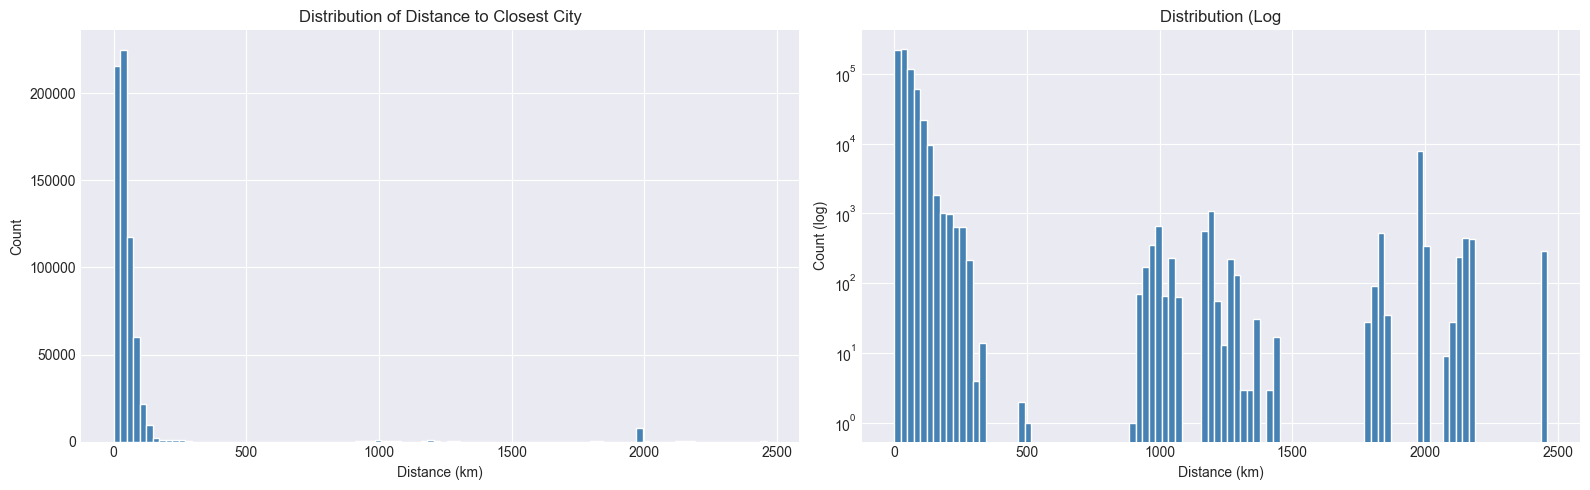

In [145]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# histogram
axes[0].hist(df_migratory['distance_km'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Distance to Closest City')
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Count')

# log scale histogram (useful if data is right-skewed)
axes[1].hist(df_migratory['distance_km'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Distribution (Log')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Count (log)')


plt.tight_layout()
plt.savefig("distance_distribution.png", dpi=150)
plt.show()

### Distance Aggregations

The following cells calculate the average distance to the closest city across three groupings:
1. **Per year** — how the average distance changes over time
2. **Per species** — average across all years for each species
3. **Per species per year** — the most granular breakdown

In [146]:
# --- 1. Average distance to closest city per year ---
dist_by_year = (
    df_migratory
    .dropna(subset=['distance_km', 'year'])
    .groupby('year')['distance_km']
    .agg(mean_distance_km='mean', median_distance_km='median', n_observations='count')
    .reset_index()
    .sort_values('year')
)
dist_by_year['year'] = dist_by_year['year'].astype(int)

print("Average distance to closest city per year:")
print(dist_by_year.to_string(index=False))

Average distance to closest city per year:
 year  mean_distance_km  median_distance_km  n_observations
 2017         90.610106               35.56           59795
 2018         89.488594               35.54           70218
 2019         81.937664               35.73           91941
 2020         77.234132               35.62          104121
 2021         79.641804               36.12          146936
 2022         70.922299               35.70          195581


In [147]:
# --- 2. Average distance to closest city per species (across all years) ---
dist_by_species = (
    df_migratory
    .dropna(subset=['distance_km', 'COMMON NAME'])
    .groupby('COMMON NAME')['distance_km']
    .agg(mean_distance_km='mean', median_distance_km='median', n_observations='count')
    .reset_index()
    .sort_values('mean_distance_km', ascending=False)
)

print("Average distance to closest city per species (all years combined):")
print(dist_by_species.to_string(index=False))

Average distance to closest city per species (all years combined):
           COMMON NAME  mean_distance_km  median_distance_km  n_observations
            Sanderling        158.837963               34.62           85484
              Red Knot        129.793454               38.99           39126
      Curlew Sandpiper        119.619915               35.26           36594
          Little Stint         97.890082               35.65           51689
                  Ruff         74.425911               37.93          109964
        Wood Sandpiper         52.292325               35.17           74871
       Green Sandpiper         48.148268               35.56          173660
              Garganey         45.450144               32.55           52675
European Honey-buzzard         42.706787               38.84           44529


In [148]:
# --- 3. Average distance to closest city per species per year ---
dist_by_species_year = (
    df_migratory
    .dropna(subset=['distance_km', 'COMMON NAME', 'year'])
    .groupby(['COMMON NAME', 'year'])['distance_km']
    .agg(mean_distance_km='mean', median_distance_km='median', n_observations='count')
    .reset_index()
    .sort_values(['COMMON NAME', 'year'])
)
dist_by_species_year['year'] = dist_by_species_year['year'].astype(int)

print("Average distance to closest city per species per year:")
print(dist_by_species_year.to_string(index=False))

# Optionally pivot for a cleaner species × year view
pivot_mean = dist_by_species_year.pivot(index='COMMON NAME', columns='year', values='mean_distance_km').round(2)
print("\nPivot table — mean distance (km) by species × year:")
print(pivot_mean.to_string())

Average distance to closest city per species per year:
           COMMON NAME  year  mean_distance_km  median_distance_km  n_observations
      Curlew Sandpiper  2017        157.199957              35.030            3004
      Curlew Sandpiper  2018        122.924719              34.620            3785
      Curlew Sandpiper  2019        107.419646              34.855            4854
      Curlew Sandpiper  2020        112.330849              35.260            6045
      Curlew Sandpiper  2021        150.485339              37.830            6932
      Curlew Sandpiper  2022         99.904219              35.260           11974
European Honey-buzzard  2017         42.514370              39.970            4583
European Honey-buzzard  2018         43.556253              39.970            5928
European Honey-buzzard  2019         42.682589              39.970            7220
European Honey-buzzard  2020         42.077568              35.825            7772
European Honey-buzzard  2021    

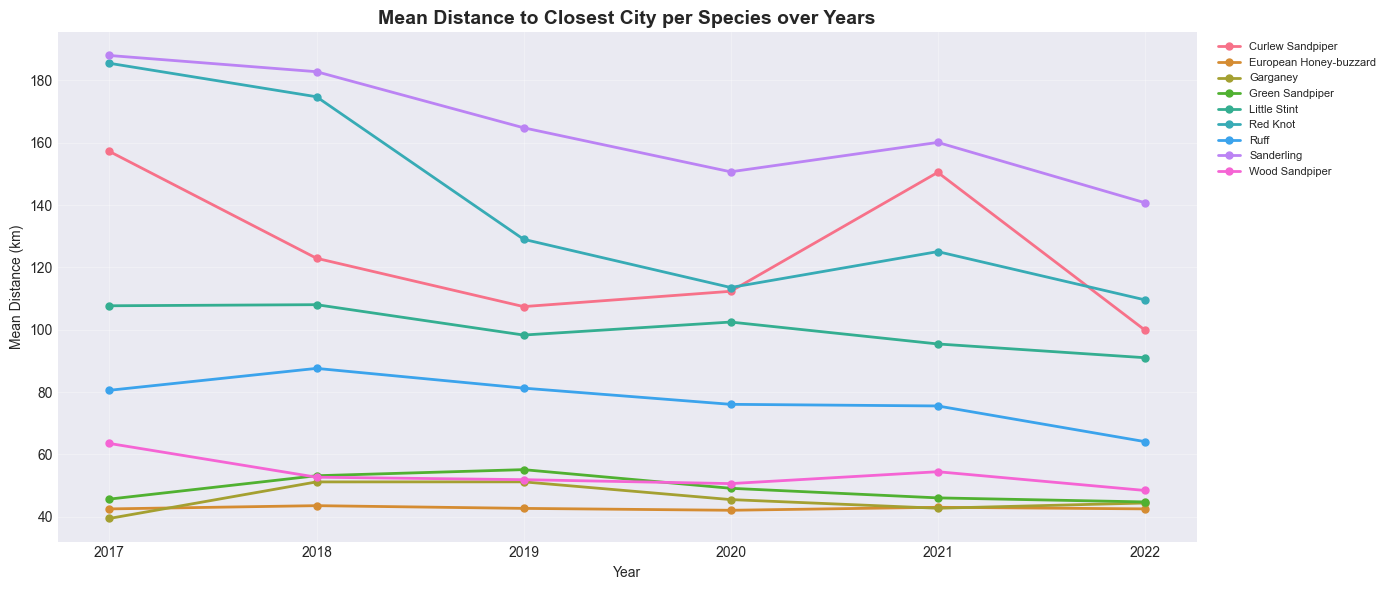

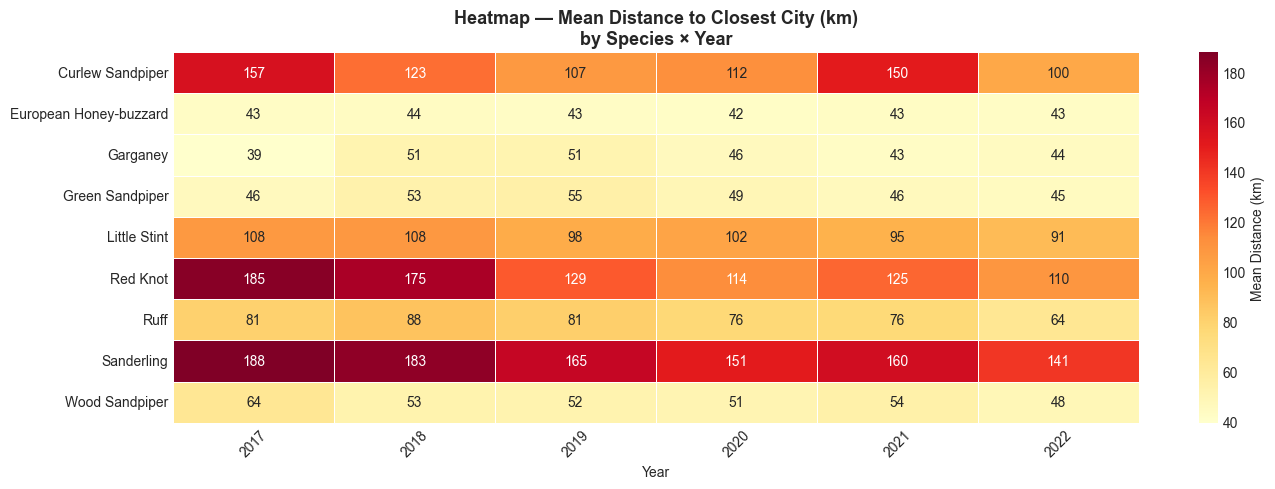

In [149]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── Colour palette ──────────────────────────────────────────────────────────
species_list = dist_by_species_year['COMMON NAME'].unique()
palette = dict(zip(species_list, sns.color_palette("husl", len(species_list))))

# ============================================================
# PLOT 1 — Line plot: mean distance per species over years
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))

for species, grp in dist_by_species_year.groupby('COMMON NAME'):
    ax.plot(grp['year'], grp['mean_distance_km'],
            marker='o', linewidth=2, markersize=5,
            label=species, color=palette[species])

ax.set_title('Mean Distance to Closest City per Species over Years', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Mean Distance (km)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, framealpha=0.7)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dist_species_year_lineplot.png', dpi=150)
plt.show()

# ============================================================
# PLOT 2 — Heatmap: pivot_mean (species × year)
# ============================================================
fig, ax = plt.subplots(figsize=(14, max(5, len(species_list) * 0.45)))

sns.heatmap(
    pivot_mean,
    ax=ax,
    cmap='YlOrRd',
    annot=True, fmt='.0f',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Mean Distance (km)'}
)

ax.set_title('Heatmap — Mean Distance to Closest City (km)\nby Species × Year',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('dist_species_year_heatmap.png', dpi=150)
plt.show()


In [150]:
print(df_migratory['distance_km'].describe())
print(f"\nMedian:  {df_migratory['distance_km'].median():.2f} km")
print(f"Skewness: {df_migratory['distance_km'].skew():.2f}")
print(f"% within 10km:  {(df_migratory['distance_km'] <= 10).mean()*100:.1f}%")
print(f"% within 50km:  {(df_migratory['distance_km'] <= 50).mean()*100:.1f}%")
print(f"% within 100km: {(df_migratory['distance_km'] <= 100).mean()*100:.1f}%")

count    668592.000000
mean         79.046966
std         257.008664
min           0.060000
25%          20.760000
50%          35.680000
75%          58.930000
max        2460.870000
Name: distance_km, dtype: float64

Median:  35.68 km
Skewness: 6.98
% within 10km:  8.8%
% within 50km:  66.6%
% within 100km: 92.6%


### by night/day time activity

In [151]:
# ── 1. Average distance per migration group (all years combined) ─────────────
dist_by_group = (
    combined_df
    .dropna(subset=['distance_km', 'migration_group'])
    .groupby('migration_group')['distance_km']
    .agg(mean_distance_km='mean', median_distance_km='median', n_observations='count')
    .reset_index()
    .sort_values('mean_distance_km', ascending=False)
)

print("Average distance to closest city per migration group:")
print(dist_by_group.to_string(index=False))

# ── 2. Average distance per migration group per year ─────────────────────────
dist_by_group_year = (
    combined_df
    .dropna(subset=['distance_km', 'migration_group', 'year'])
    .groupby(['migration_group', 'year'])['distance_km']
    .agg(mean_distance_km='mean', median_distance_km='median', n_observations='count')
    .reset_index()
    .sort_values(['migration_group', 'year'])
)
dist_by_group_year['year'] = dist_by_group_year['year'].astype(int)

print("\nAverage distance to closest city per migration group per year:")
print(dist_by_group_year.to_string(index=False))

# ── 3. Average distance per migration group per species ───────────────────────
dist_by_group_species = (
    combined_df
    .dropna(subset=['distance_km', 'migration_group', 'COMMON NAME'])
    .groupby(['migration_group', 'COMMON NAME'])['distance_km']
    .agg(mean_distance_km='mean', median_distance_km='median', n_observations='count')
    .reset_index()
    .sort_values(['migration_group', 'mean_distance_km'], ascending=[True, False])
)

print("\nAverage distance to closest city per migration group per species:")
print(dist_by_group_species.to_string(index=False))

# ── Pivot: migration group × year ─────────────────────────────────────────────
pivot_group_year = dist_by_group_year.pivot(
    index='migration_group', columns='year', values='mean_distance_km'
).round(2)

print("\nPivot table — mean distance (km) by migration group × year:")
print(pivot_group_year.to_string())

Average distance to closest city per migration group:
migration_group  mean_distance_km  median_distance_km  n_observations
      nocturnal         81.639961               35.65          624063
        diurnal         42.706787               38.84           44529

Average distance to closest city per migration group per year:
migration_group  year  mean_distance_km  median_distance_km  n_observations
        diurnal  2017         42.514370              39.970            4583
        diurnal  2018         43.556253              39.970            5928
        diurnal  2019         42.682589              39.970            7220
        diurnal  2020         42.077568              35.825            7772
        diurnal  2021         43.033510              36.550            8596
        diurnal  2022         42.524878              36.140           10430
      nocturnal  2017         94.602404              35.260           55212
      nocturnal  2018         93.723886              35.260     

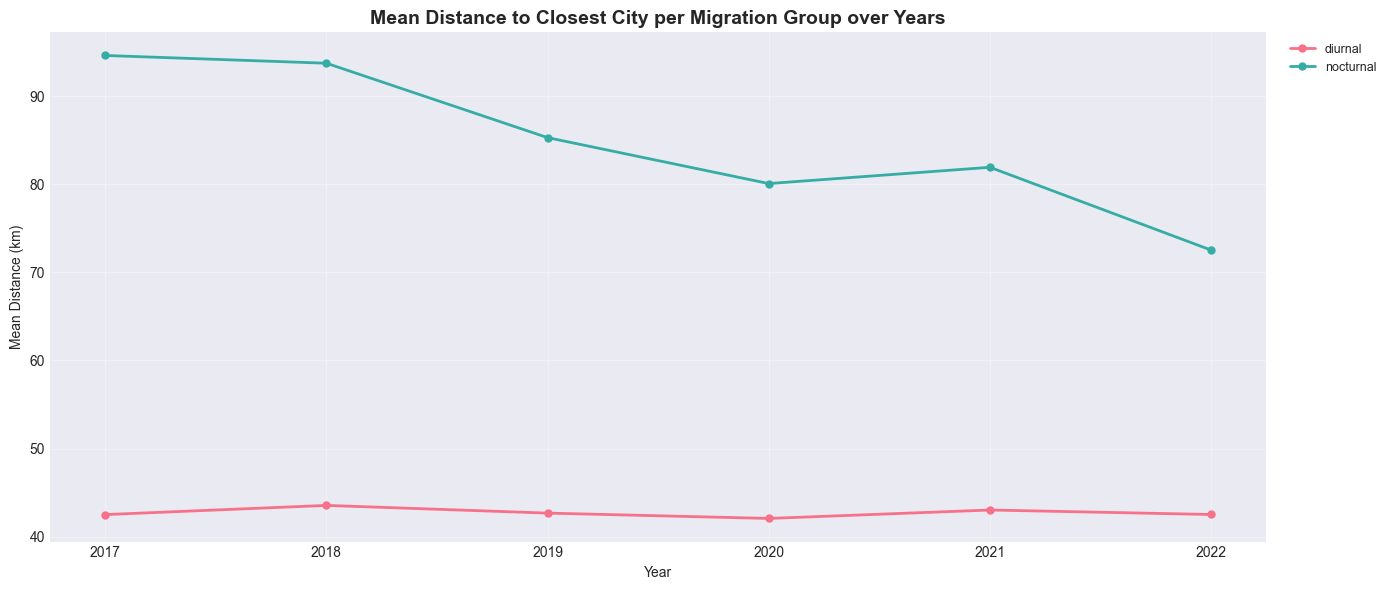

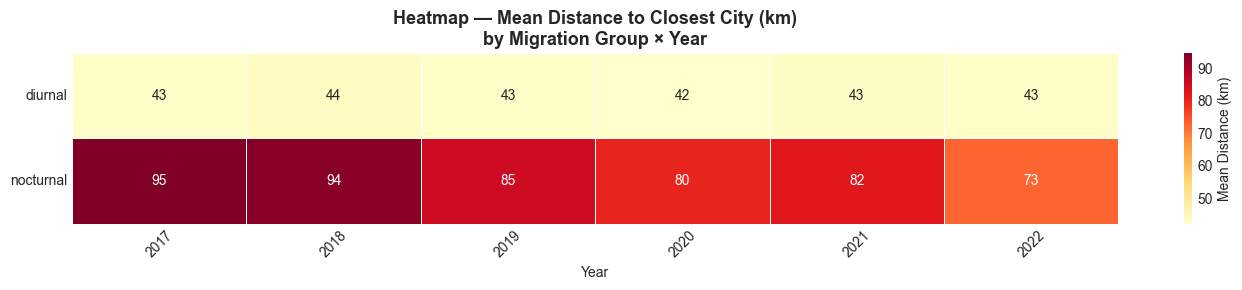

In [152]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── Colour palette ───────────────────────────────────────────────────────────
group_list = dist_by_group_year['migration_group'].unique()
palette = dict(zip(group_list, sns.color_palette("husl", len(group_list))))

# ============================================================
# PLOT 1 — Line plot: mean distance per migration group over years
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))

for group, grp in dist_by_group_year.groupby('migration_group'):
    ax.plot(grp['year'], grp['mean_distance_km'],
            marker='o', linewidth=2, markersize=5,
            label=group, color=palette[group])

ax.set_title('Mean Distance to Closest City per Migration Group over Years', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Mean Distance (km)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, framealpha=0.7)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dist_group_year_lineplot.png', dpi=150)
plt.show()

# ============================================================
# PLOT 2 — Heatmap: migration group × year
# ============================================================
fig, ax = plt.subplots(figsize=(14, max(3, len(group_list) * 0.8)))

sns.heatmap(
    pivot_group_year,
    ax=ax,
    cmap='YlOrRd',
    annot=True, fmt='.0f',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Mean Distance (km)'}
)

ax.set_title('Heatmap — Mean Distance to Closest City (km)\nby Migration Group × Year',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('dist_group_year_heatmap.png', dpi=150)
plt.show()